# 01b  -  Exploratory Data Analysis

**Run after `01_health_insurance_labeling.ipynb`**

**Inputs:** raw datasets + `outputs/health_insurance_labeled.csv`  
**Outputs:** figures in `figures/`

In [1]:
exec(open('00_config.py').read())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Credit card: combine Sparkov train + test
cc = pd.concat([pd.read_csv(p, index_col=0)
                for p in [CREDIT_CARD_TRAIN_CSV, CREDIT_CARD_TEST_CSV]
                if os.path.exists(p)], ignore_index=True)
if not len(cc):
    raise FileNotFoundError('fraudTrain.csv / fraudTest.csv not found in data/')
cc = cc.rename(columns={CC_RAW_TARGET: TARGET_COL})
cc = cc.drop(columns=[c for c in ['trans_num','unix_time','Unnamed: 0'] if c in cc.columns], errors='ignore')

# Mobile money
for p in [MOMSIM_CSV, MOMSIM_CSV_ALT]:
    if os.path.exists(p):
        mm = pd.read_csv(p)
        break
else:
    raise FileNotFoundError('MoMTSim_transactions.csv not found in data/')
if 'isFraud' in mm.columns:
    mm = mm.rename(columns={'isFraud': TARGET_COL})

# Health insurance (labeled in NB01)
hi = pd.read_csv(HI_LABELED_CSV)

print(f'Credit Card  : {cc.shape}  fraud={cc[TARGET_COL].mean():.3%}')
print(f'Mobile Money : {mm.shape}  fraud={mm[TARGET_COL].mean():.3%}')
print(f'Health Ins.  : {hi.shape}  fraud={hi[TARGET_COL].mean():.3%}')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH
Credit Card  : (1852394, 20)  fraud=0.521%
Mobile Money : (550358, 10)  fraud=54.843%
Health Ins.  : (2655, 36)  fraud=41.620%


## 1. Dataset Overview

In [2]:
for name, df in [('Credit Card', cc), ('Mobile Money', mm), ('Health Insurance', hi)]:
    print('=' * 55)
    print(name)
    print('=' * 55)
    print(df.select_dtypes(include='number').describe().round(3).to_string())
    print(f'Missing: {df.isnull().sum().sum()}  |  Duplicates: {df.duplicated().sum()}\n')

Credit Card
             cc_num          amt          zip          lat         long     city_pop    merch_lat   merch_long  fraud_label
count  1.852394e+06  1852394.000  1852394.000  1852394.000  1852394.000  1852394.000  1852394.000  1852394.000  1852394.000
mean   4.173860e+17       70.064    48813.258       38.539      -90.228    88643.675       38.539      -90.228        0.005
std    1.309115e+18      159.254    26881.846        5.071       13.748   301487.618        5.106       13.760        0.072
min    6.041621e+10        1.000     1257.000       20.027     -165.672       23.000       19.027     -166.672        0.000
25%    1.800429e+14        9.640    26237.000       34.669      -96.798      741.000       34.740      -96.899        0.000
50%    3.521417e+15       47.450    48174.000       39.354      -87.477     2443.000       39.369      -87.441        0.000
75%    4.642255e+15       83.100    72042.000       41.940      -80.158    20328.000       41.956      -80.245        0.

## 2. Class Imbalance

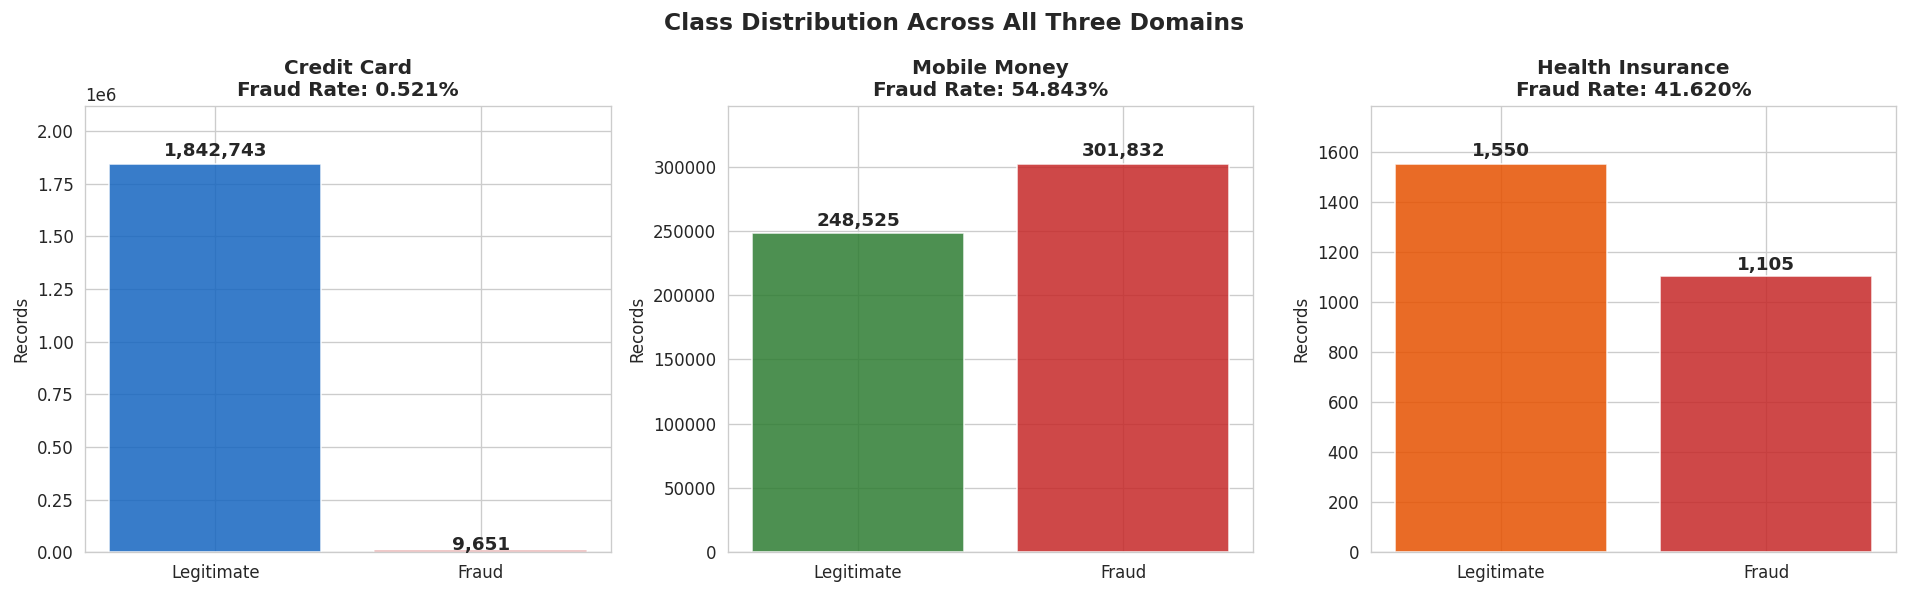

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
domains = [('Credit Card', cc, '#1565C0'), ('Mobile Money', mm, '#2E7D32'), ('Health Insurance', hi, '#E65100')]

for ax, (name, df, color) in zip(axes, domains):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars   = ax.bar(['Legitimate','Fraud'], [counts.get(0,0), counts.get(1,0)],
                    color=[color,'#C62828'], alpha=0.85, edgecolor='white')
    for bar, cnt in zip(bars, [counts.get(0,0), counts.get(1,0)]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{cnt:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'{name}\nFraud Rate: {df[TARGET_COL].mean():.3%}', fontweight='bold')
    ax.set_ylabel('Records')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Class Distribution Across All Three Domains', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs(FIGURE_DIR, exist_ok=True)
plt.savefig(os.path.join(FIGURE_DIR, 'eda_01_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Credit Card  -  Amount, Category, Hour, Geography

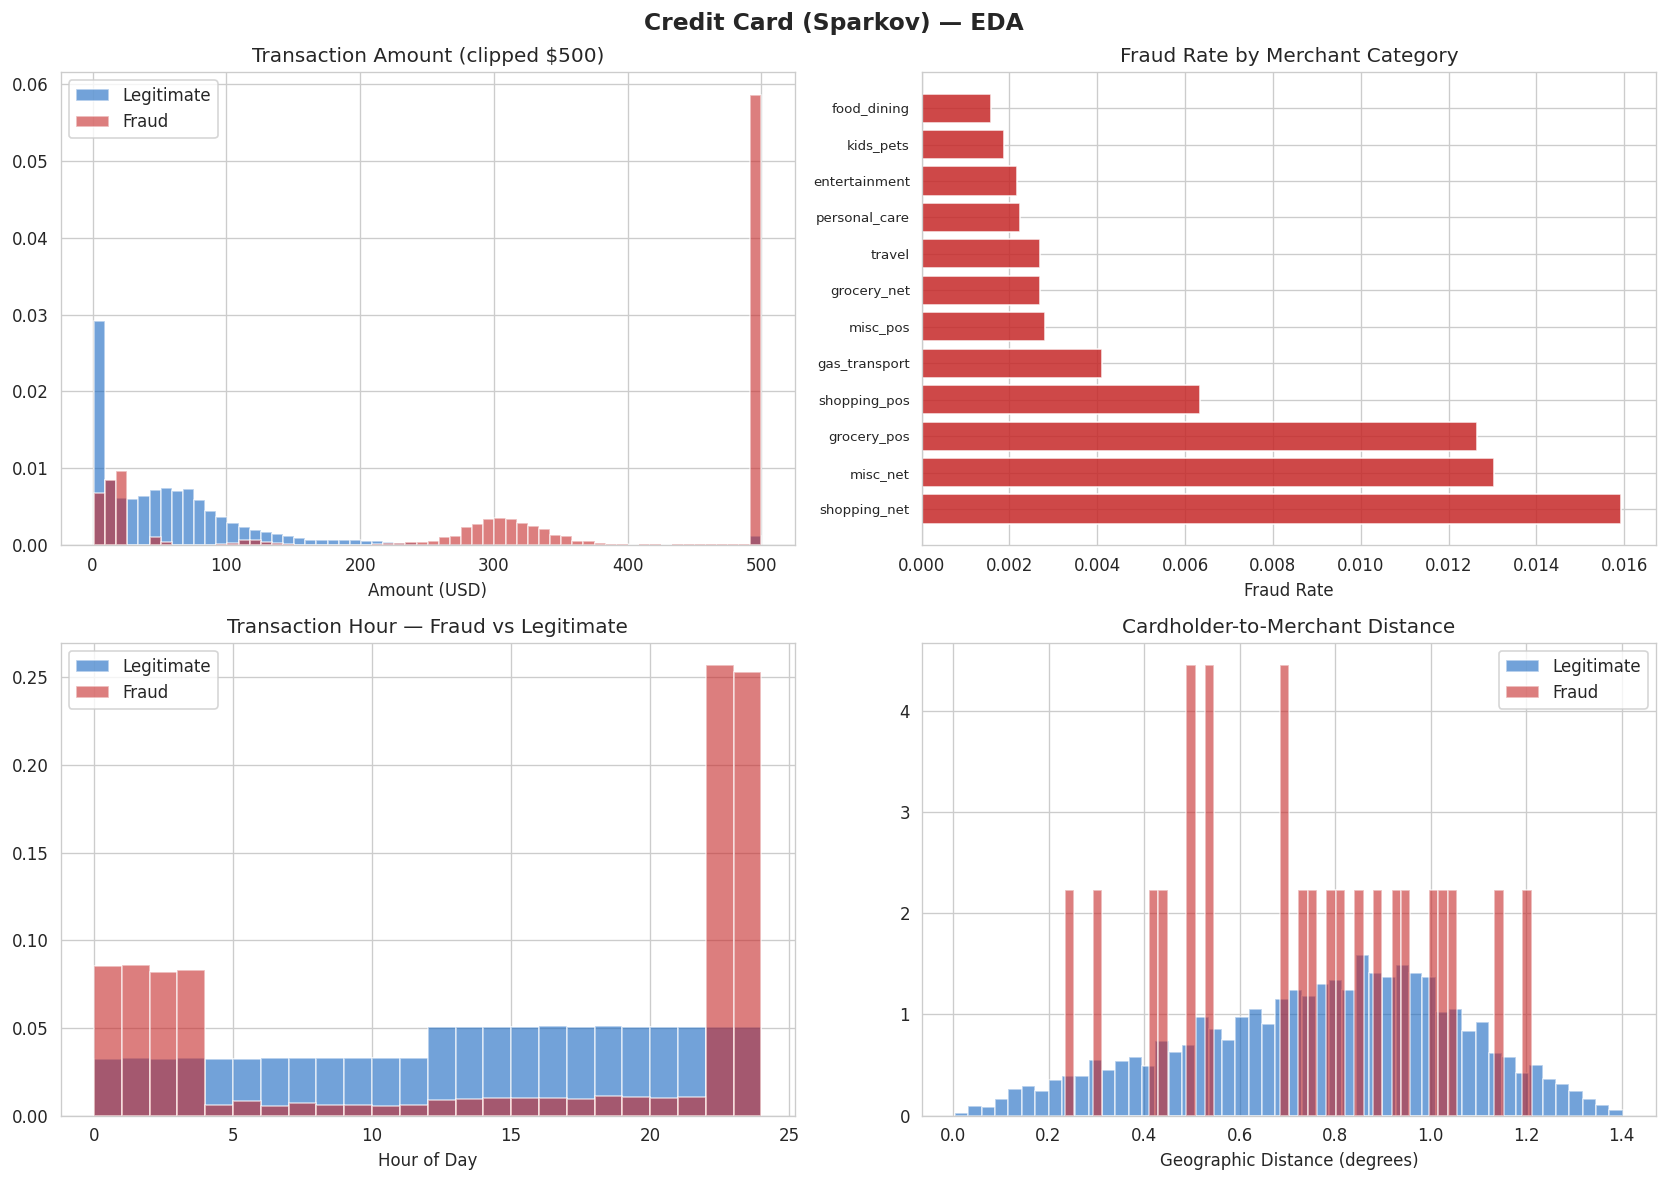

Fraud amount median: $390.00  vs  Legit: $47.24


In [4]:
# Extract hour from timestamp for plotting
cc['hour_of_day'] = pd.to_datetime(cc['trans_date_trans_time']).dt.hour

legit = cc[cc[TARGET_COL] == 0]
fraud = cc[cc[TARGET_COL] == 1]
amt_col = 'amt'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
axes[0,0].hist(legit[amt_col].clip(upper=500), bins=60, alpha=0.6, label='Legitimate', color='#1565C0', density=True)
axes[0,0].hist(fraud[amt_col].clip(upper=500), bins=60, alpha=0.6, label='Fraud',      color='#C62828', density=True)
axes[0,0].set_title('Transaction Amount (clipped $500)')
axes[0,0].set_xlabel('Amount (USD)')
axes[0,0].legend()

# Fraud rate by category
cat_fraud = cc.groupby('category')[TARGET_COL].mean().sort_values(ascending=False).head(12)
axes[0,1].barh(range(len(cat_fraud)), cat_fraud.values, color='#C62828', alpha=0.85)
axes[0,1].set_yticks(range(len(cat_fraud)))
axes[0,1].set_yticklabels([str(x)[:20] for x in cat_fraud.index], fontsize=8)
axes[0,1].set_title('Fraud Rate by Merchant Category')
axes[0,1].set_xlabel('Fraud Rate')

# Hour distribution
axes[1,0].hist(legit['hour_of_day'], bins=24, range=(0,24), alpha=0.6, label='Legitimate', color='#1565C0', density=True)
axes[1,0].hist(fraud['hour_of_day'], bins=24, range=(0,24), alpha=0.6, label='Fraud',      color='#C62828', density=True)
axes[1,0].set_title('Transaction Hour  -  Fraud vs Legitimate')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].legend()

# Geographic distance
sample = cc.sample(min(5000, len(cc)), random_state=42)
geo    = np.sqrt((sample['lat'] - sample['merch_lat'])**2 + (sample['long'] - sample['merch_long'])**2)
is_fraud = sample[TARGET_COL].astype(bool)
axes[1,1].hist(geo[~is_fraud].clip(upper=10), bins=50, alpha=0.6, label='Legitimate', color='#1565C0', density=True)
axes[1,1].hist(geo[is_fraud].clip(upper=10),  bins=50, alpha=0.6, label='Fraud',      color='#C62828', density=True)
axes[1,1].set_title('Cardholder-to-Merchant Distance')
axes[1,1].set_xlabel('Geographic Distance (degrees)')
axes[1,1].legend()

plt.suptitle('Credit Card (Sparkov)  -  EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_02_credit_card.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Fraud amount median: ${fraud[amt_col].median():.2f}  vs  Legit: ${legit[amt_col].median():.2f}')

## 4. Mobile Money  -  Transaction Patterns

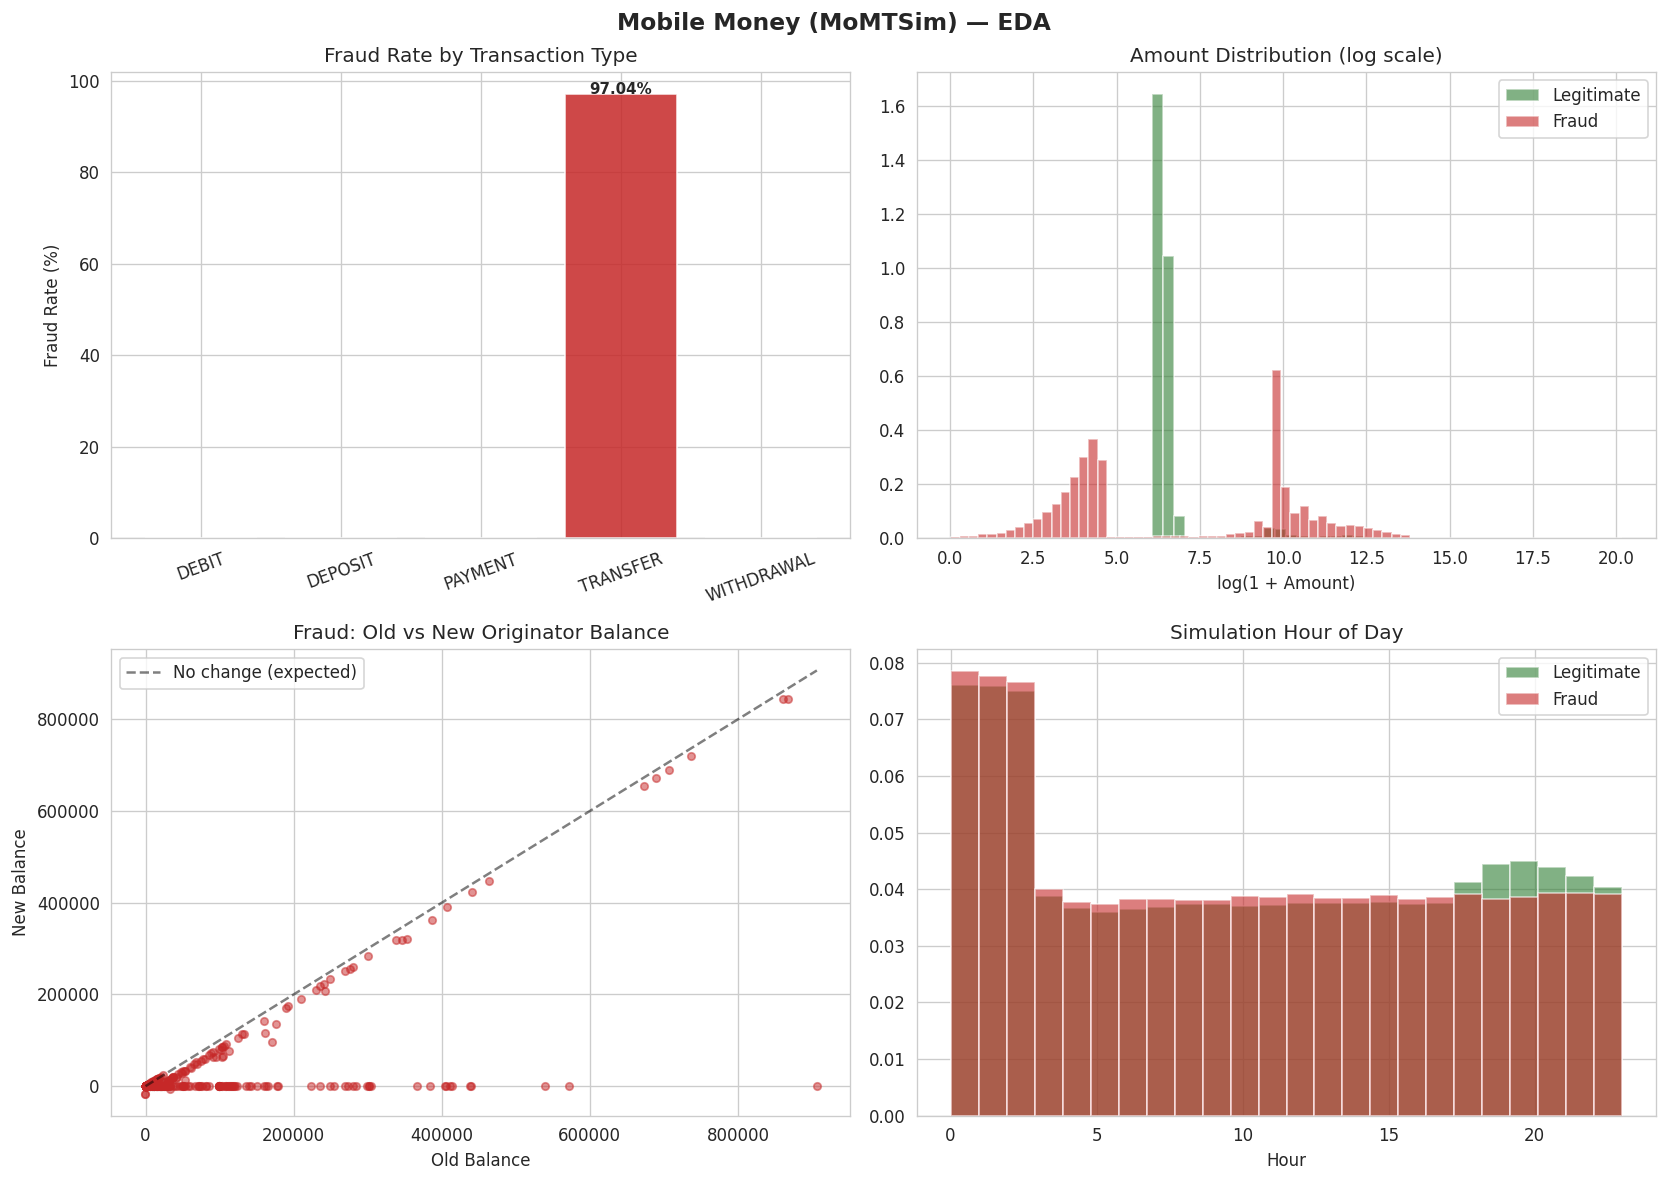

Fraud only occurs in: ['TRANSFER']


In [5]:
mm['hour_sim'] = mm['step'] % 24
mm_s = mm.sample(min(50000, len(mm)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by transaction type
by_type = mm.groupby('transactionType')[TARGET_COL].agg(['sum','mean','count']).reset_index()
by_type.columns = ['type','fraud_count','fraud_rate','total']
bars = axes[0,0].bar(by_type['type'], by_type['fraud_rate'] * 100,
                     color=['#C62828' if r > 0 else '#2E7D32' for r in by_type['fraud_rate']], alpha=0.85)
axes[0,0].set_title('Fraud Rate by Transaction Type')
axes[0,0].set_ylabel('Fraud Rate (%)')
axes[0,0].tick_params(axis='x', rotation=20)
for bar, rate in zip(bars, by_type['fraud_rate']):
    if rate > 0:
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{rate:.2%}', ha='center', fontsize=9, fontweight='bold')

# Amount distribution (log scale)
axes[0,1].hist(np.log1p(mm_s[mm_s[TARGET_COL]==0]['amount']), bins=50, alpha=0.6,
               label='Legitimate', color='#2E7D32', density=True)
axes[0,1].hist(np.log1p(mm_s[mm_s[TARGET_COL]==1]['amount']), bins=50, alpha=0.6,
               label='Fraud',      color='#C62828', density=True)
axes[0,1].set_title('Amount Distribution (log scale)')
axes[0,1].set_xlabel('log(1 + Amount)')
axes[0,1].legend()

# Balance inconsistency  -  fraud cases should zero out the originator balance
fraud_mm = mm[mm[TARGET_COL] == 1].head(500)
axes[1,0].scatter(fraud_mm['oldBalInitiator'], fraud_mm['newBalInitiator'], alpha=0.5, color='#C62828', s=20)
mx = max(fraud_mm['oldBalInitiator'].max(), 1)
axes[1,0].plot([0, mx], [0, mx], 'k--', alpha=0.5, label='No change (expected)')
axes[1,0].set_title('Fraud: Old vs New Originator Balance')
axes[1,0].set_xlabel('Old Balance'); axes[1,0].set_ylabel('New Balance')
axes[1,0].legend()

# Hour distribution
axes[1,1].hist(mm[mm[TARGET_COL]==0]['hour_sim'], bins=24, alpha=0.6, label='Legitimate', color='#2E7D32', density=True)
axes[1,1].hist(mm[mm[TARGET_COL]==1]['hour_sim'], bins=24, alpha=0.6, label='Fraud',      color='#C62828', density=True)
axes[1,1].set_title('Simulation Hour of Day')
axes[1,1].set_xlabel('Hour')
axes[1,1].legend()

plt.suptitle('Mobile Money (MoMTSim)  -  EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_03_mobile_money.png'), dpi=150, bbox_inches='tight')
plt.show()

fraud_types = mm.groupby('transactionType')[TARGET_COL].sum()
print(f'Fraud only occurs in: {fraud_types[fraud_types > 0].index.tolist()}')

## 5. Health Insurance  -  G-DRG Tariff Analysis

Based on Sowah et al. (2019).

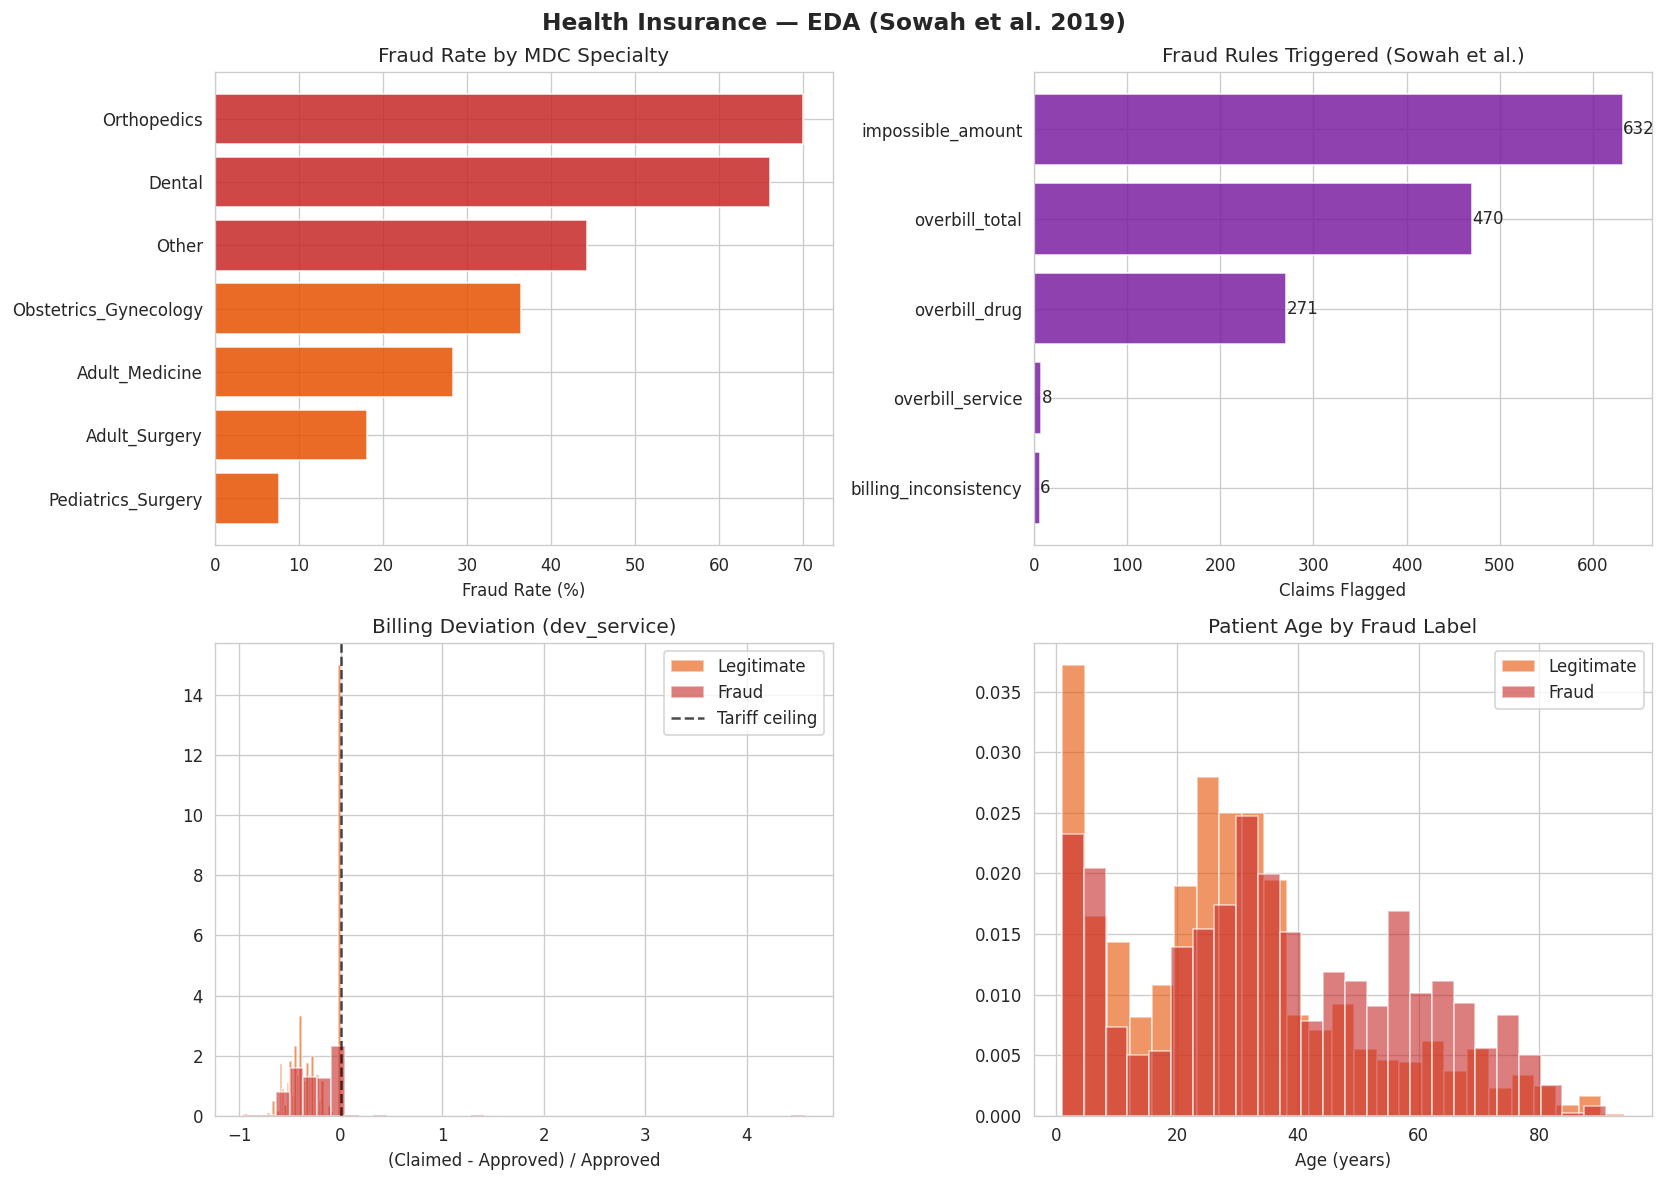

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by MDC specialty
if 'MDC_Specialty' in hi.columns:
    mdc = hi.groupby('MDC_Specialty')[TARGET_COL].agg(['mean','count']).reset_index()
    mdc.columns = ['MDC','fraud_rate','count']
    mdc = mdc[mdc['count'] >= 3].sort_values('fraud_rate')
    med = mdc['fraud_rate'].median()
    axes[0,0].barh(mdc['MDC'], mdc['fraud_rate'] * 100,
                   color=['#C62828' if r > med else '#E65100' for r in mdc['fraud_rate']], alpha=0.85)
    axes[0,0].set_title('Fraud Rate by MDC Specialty')
    axes[0,0].set_xlabel('Fraud Rate (%)')

# Rule breakdown
flag_cols = [c for c in ['overbill_service','overbill_drug','overbill_total',
                          'billing_inconsistency','impossible_amount'] if c in hi.columns]
if flag_cols:
    fc = hi[flag_cols].sum().sort_values()
    axes[0,1].barh(fc.index, fc.values, color='#7B1FA2', alpha=0.85)
    axes[0,1].set_title('Fraud Rules Triggered (Sowah et al.)')
    axes[0,1].set_xlabel('Claims Flagged')
    for i, v in enumerate(fc.values):
        axes[0,1].text(v + 0.5, i, str(int(v)), va='center')

# Billing deviation distribution
dev_col = next((c for c in hi.columns if c.startswith('dev_')), None)
if dev_col:
    axes[1,0].hist(hi[hi[TARGET_COL]==0][dev_col].clip(-2,5).dropna(), bins=40, alpha=0.6,
                   label='Legitimate', color='#E65100', density=True)
    axes[1,0].hist(hi[hi[TARGET_COL]==1][dev_col].clip(-2,5).dropna(), bins=40, alpha=0.6,
                   label='Fraud',      color='#C62828', density=True)
    axes[1,0].axvline(0, color='black', linestyle='--', alpha=0.7, label='Tariff ceiling')
    axes[1,0].set_title(f'Billing Deviation ({dev_col})')
    axes[1,0].set_xlabel('(Claimed - Approved) / Approved')
    axes[1,0].legend()

# Age distribution
if 'Age' in hi.columns:
    age = pd.to_numeric(hi['Age'], errors='coerce')
    axes[1,1].hist(age[hi[TARGET_COL]==0].dropna(), bins=25, alpha=0.6, label='Legitimate', color='#E65100', density=True)
    axes[1,1].hist(age[hi[TARGET_COL]==1].dropna(), bins=25, alpha=0.6, label='Fraud',      color='#C62828', density=True)
    axes[1,1].set_title('Patient Age by Fraud Label')
    axes[1,1].set_xlabel('Age (years)')
    axes[1,1].legend()

plt.suptitle('Health Insurance  -  EDA (Sowah et al. 2019)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_04_health_insurance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Cross-Domain Comparison

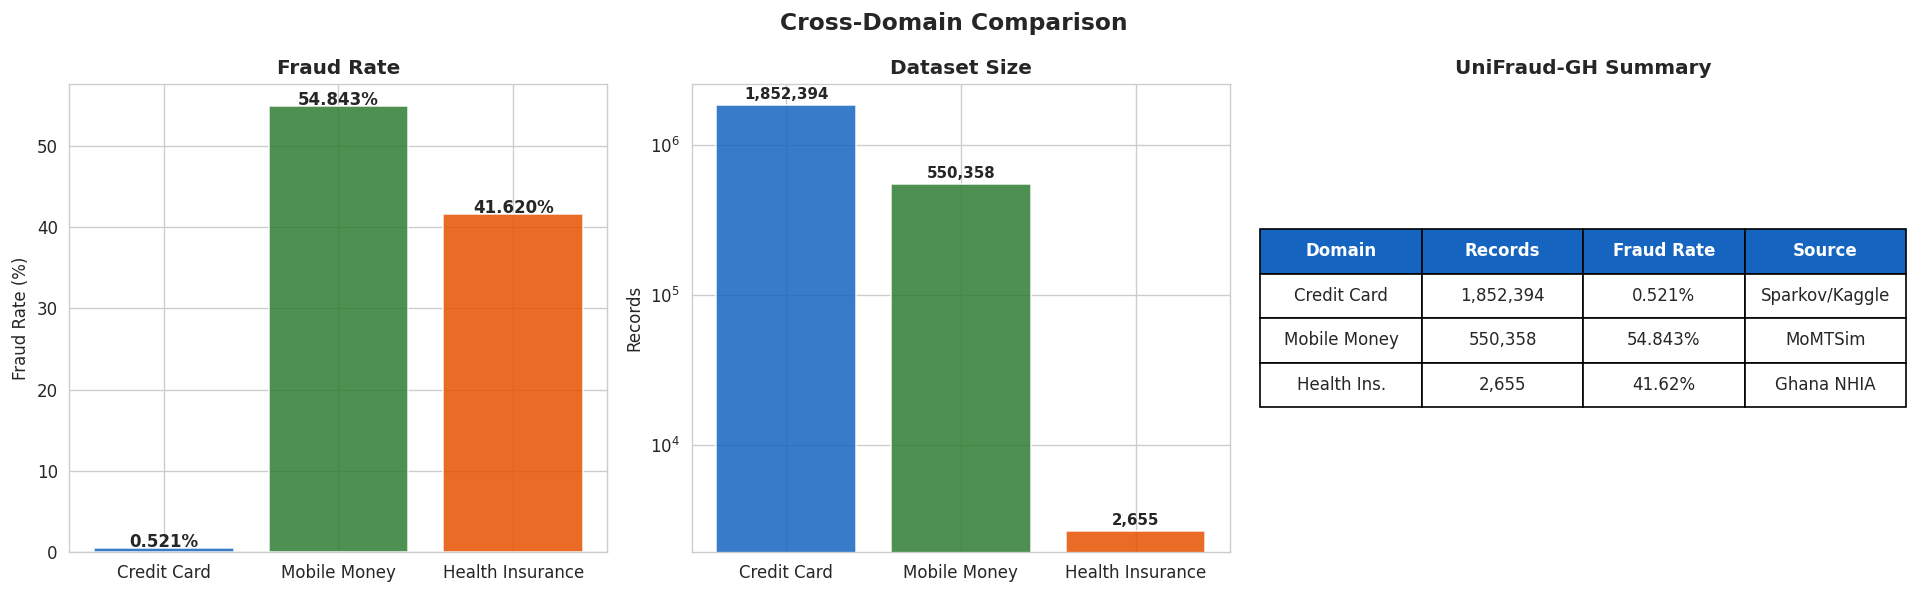

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors       = ['#1565C0','#2E7D32','#E65100']
domain_names = ['Credit Card','Mobile Money','Health Insurance']
fraud_rates  = [cc[TARGET_COL].mean(), mm[TARGET_COL].mean(), hi[TARGET_COL].mean()]
sizes        = [len(cc), len(mm), len(hi)]

# Fraud rates
axes[0].bar(domain_names, [r*100 for r in fraud_rates], color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Fraud Rate', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
for i, r in enumerate(fraud_rates):
    axes[0].text(i, r*100 + 0.1, f'{r:.3%}', ha='center', fontweight='bold')

# Dataset sizes (log scale)
axes[1].bar(domain_names, sizes, color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Dataset Size', fontweight='bold')
axes[1].set_ylabel('Records')
axes[1].set_yscale('log')
for i, s in enumerate(sizes):
    axes[1].text(i, s*1.1, f'{s:,}', ha='center', fontweight='bold', fontsize=9)

# Summary table
axes[2].axis('off')
tbl = axes[2].table(
    cellText=[['Credit Card',  f'{len(cc):,}',  f'{cc[TARGET_COL].mean():.3%}', 'Sparkov/Kaggle'],
              ['Mobile Money', f'{len(mm):,}',  f'{mm[TARGET_COL].mean():.3%}', 'MoMTSim'],
              ['Health Ins.',  f'{len(hi):,}',  f'{hi[TARGET_COL].mean():.2%}', 'Ghana NHIA']],
    colLabels=['Domain','Records','Fraud Rate','Source'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)
for j in range(4):
    tbl[0,j].set_facecolor('#1565C0')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
axes[2].set_title('UniFraud-GH Summary', fontweight='bold')

plt.suptitle('Cross-Domain Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_05_cross_domain.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Heatmaps

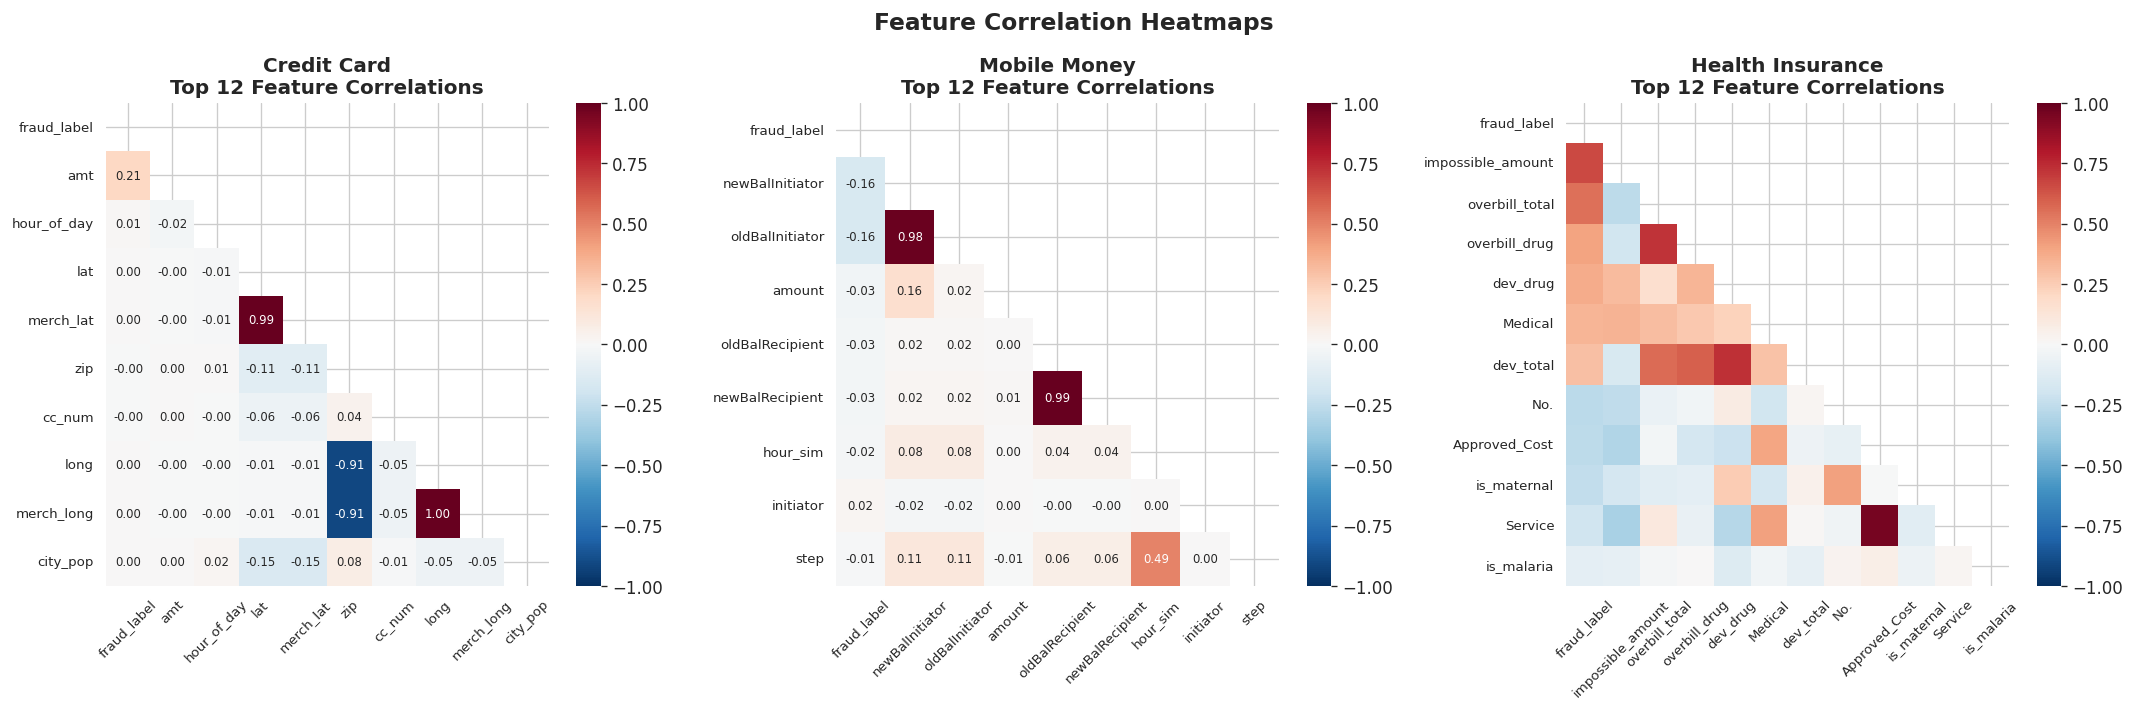

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, df, color) in zip(axes, domains):
    num_df = df.select_dtypes(include='number')
    # Pick the 12 features most correlated with the target
    if TARGET_COL in num_df.columns:
        top_cols = num_df.corr()[TARGET_COL].abs().sort_values(ascending=False).head(12).index.tolist()
    else:
        top_cols = num_df.columns[:12].tolist()
    corr = num_df[top_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=(len(top_cols) <= 10), fmt='.2f', annot_kws={'size':7})
    ax.set_title(f'{name}\nTop 12 Feature Correlations', fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Feature Correlation Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_06_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

In [9]:
print('=' * 60)
print('UNIFRAUD-GH  -  EDA SUMMARY')
print('=' * 60)

summary = pd.DataFrame({
    'Domain':       ['Credit Card','Mobile Money','Health Insurance'],
    'Records':      [f'{len(cc):,}', f'{len(mm):,}', f'{len(hi):,}'],
    'Fraud Cases':  [f'{cc[TARGET_COL].sum():,}', f'{mm[TARGET_COL].sum():,}', f'{hi[TARGET_COL].sum():,}'],
    'Fraud Rate':   [f'{cc[TARGET_COL].mean():.3%}', f'{mm[TARGET_COL].mean():.3%}', f'{hi[TARGET_COL].mean():.3%}'],
    'Features':     [str(cc.shape[1]-1), str(mm.shape[1]-1), str(hi.shape[1]-1)],
})
print(summary.to_string(index=False))

fraud_types = mm.groupby('transactionType')[TARGET_COL].sum()
print(f'\nCC:  Fraud peaks at night -> unusual_hour flag important')
print(f'MM:  Fraud only in: {fraud_types[fraud_types > 0].index.tolist()}')
print(f'HI:  Dominant fraud type is overbilling (Sowah et al. 2019)')
print(f'\n Next: 02_preprocessing.ipynb')

UNIFRAUD-GH  -  EDA SUMMARY
          Domain   Records Fraud Cases Fraud Rate Features
     Credit Card 1,852,394       9,651     0.521%       20
    Mobile Money   550,358   301,832.0    54.843%       10
Health Insurance     2,655       1,105    41.620%       35

CC:  Fraud peaks at night -> unusual_hour flag important
MM:  Fraud only in: ['TRANSFER']
HI:  Dominant fraud type is overbilling (Sowah et al. 2019)

 Next: 02_preprocessing.ipynb
